In [1]:
import os
import netCDF4 as netcdf
import numpy as np
import sys
maindir = os.getcwd()
sys.path.append(maindir+"/src")

PATH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP/Training-Ext/Amon/tas'

In [2]:
DIR_LIST = os.listdir(PATH)

dic_data = {}
dic_forced_response = {}

# how to center the data with respect to the monthly mean

# 1. calculate the monthly mean
# 2. subtract the monthly mean from the data
# 3. calculate the forced response by averaging over the time dimension

for idx_m, dir in enumerate(DIR_LIST):

    print(f'Processing {idx_m+1}/{len(DIR_LIST)}: {dir}')
    dir_path = os.path.join(PATH, dir)
    file_list = os.listdir(dir_path)

    dic_data[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)
    dic_forced_response[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)

    for idx_f, file in enumerate(file_list):
        print(f'  Processing {idx_f+1}/{len(file_list)}: {file}')
        file_path = os.path.join(dir_path, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        dic_data[dir][idx_f,:,:,:] = np.array(netcdf_file.variables['tas']) 
        for i in range(12):
            dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] = dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(dic_data[dir][idx_f, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        # print(f'  Tas shape: {tas.shape}')
    dic_forced_response[dir][:,:,:,:] = np.nanmean(dic_data[dir], axis=0)
    


Processing 1/5: CESM2
  Processing 1/50: tas_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc
  Processing 2/50: tas_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: tas_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: tas_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: tas_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: tas_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: tas_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: tas_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: tas_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: tas_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: tas_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: tas_mon_CESM2_historical_ssp370_

In [3]:
# read the test data
PATH_TEST = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP/Evaluation-Tier1/Amon/tas'
PATH_EVAL = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/Evaluation-Tier1/'


DIR_LIST_TEST = os.listdir(PATH_EVAL)
data_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

count = 0
for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_') and file.endswith('.nc'):
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_EVAL, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        data_test[count,:,:,:] = np.array(netcdf_file.variables['tas'][:]) 
        for i in range(12):
            data_test[count,np.arange(time.shape[0]) % 12 == i,:,:] = data_test[count,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_test[count, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        print(f'  Tas shape: {data_test[count,:,:,:].shape}')
        
        count += 1


  Processing 6/81: tas_mon_1F.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 12/81: tas_mon_1C.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 16/81: tas_mon_1H.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 26/81: tas_mon_1G.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 40/81: tas_mon_1D.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 52/81: tas_mon_1J.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 58/81: tas_mon_1A.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 60/81: tas_mon_1E.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 71/81: tas_mon_1B.195001-202212.nc
  Tas shape: (876, 72, 144)
  Processing 77/81: tas_mon_1I.195001-202212.nc
  Tas shape: (876, 72, 144)


In [4]:
# Read the ground truth data

PATH_GROUND_TRUTH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ensmeans-Tier1'

DIR_LIST_GROUND_TRUTH = os.listdir(PATH_GROUND_TRUTH)

data_ground_truth_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

count = 0 
for idx_r, file in enumerate(DIR_LIST_GROUND_TRUTH):

    if file.__contains__('.tas.'):
        
        print(f'  Processing {idx_r+1}: {file}')

        # read the ground truth data
        file_path = os.path.join(PATH_GROUND_TRUTH, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # print(netcdf_file.variables)
        print(np.array(netcdf_file.variables['arr_EM']).shape)

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        data_ground_truth_test[count,:,:,:] = np.array(netcdf_file.variables['arr_EM'])

        for i in range(12):
            data_ground_truth_test[count,np.arange(time.shape[0]) % 12 == i,:,:] = data_ground_truth_test[count,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_ground_truth_test[count, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        print(f'  Tas shape: {data_ground_truth_test[count,:,:,:].shape}')
        count += 1

  Processing 7: 1A.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 15: 1B.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 23: 1C.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 31: 1D.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 39: 1E.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 47: 1F.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 55: 1G.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 63: 1H.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)
  Processing 71: 1J.tas.EM.1950-2022.nc
(876, 72, 144)
  Tas shape: (876, 72, 144)


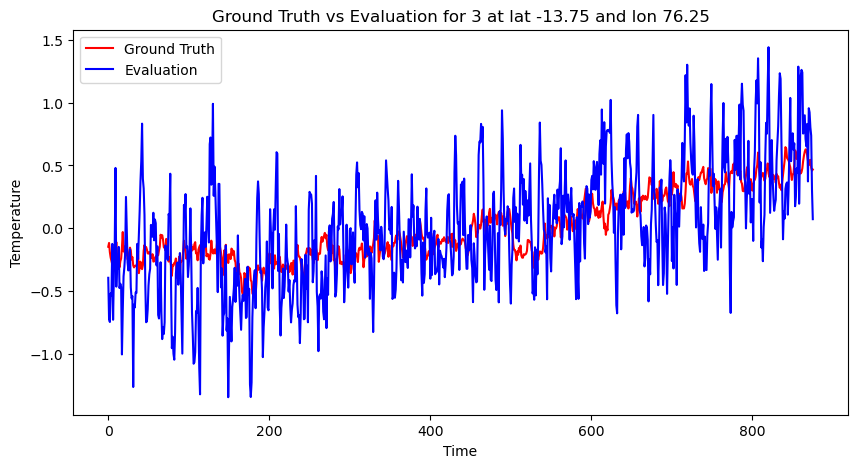

In [5]:
# check if the data is correct by plotting the ensemble mean and the evaluation data on the same plot
import matplotlib.pyplot as plt

idx_run = 3
idx_lat = 30
idx_lon = 30

x_tmp = data_ground_truth_test[idx_run,:,idx_lat,idx_lon]
y_tmp = data_test[idx_run,:,idx_lat,idx_lon]

plt.figure(figsize=(10, 5))
plt.plot(x_tmp, label='Ground Truth', color='red')
plt.plot(y_tmp, label='Evaluation', color='blue')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [6]:
import torch

def normalize_data(data, means, vars):
    """Normalize the data with respect to the monthly mean and the variance of the anomaly.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           means: numpy array of shape (runs, latitude, longitude)
           vars: numpy array of shape (runs, latitude, longitude)
       Return:
           normalized_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    normalized_data = {}
    for idx,key in enumerate(data.keys()):
        normalized_data[key] = (data[key] - means[key]) / np.sqrt(vars[key])
    return normalized_data

def merge_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    
    for idx_m,m in enumerate(x.keys()):
        
        if idx_m ==0:

            x_train = torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))
            y_train = torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))


        else:
            x_train = torch.cat([x_train, torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)
            y_train = torch.cat([y_train, torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)

        print(f'  x_train shape: {x_train.shape}')
    return x_train, y_train


def reshape_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    x_train = {}
    y_train = {}
    
    for idx_m,m in enumerate(x.keys()):
        
        x_train[m] = torch.from_numpy(x[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        y_train[m] = torch.from_numpy(y[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        print(f'  x_train shape: {x_train[m].shape}')
        print(f'  y_train shape: {y_train[m].shape}')
    return x_train, y_train

In [7]:
def yearly_average(x, months_per_year=12):
    """
    Compute the yearly average of a time series.
    Args:
        data: numpy array of shape (time, ...)
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        numpy array of shape (years, ...)
    """
    n_years = x.shape[1] // months_per_year
    data_reshaped = x.reshape(x.shape[0],n_years, months_per_year, x.shape[2],x.shape[3])
    return data_reshaped.mean(axis=2)


# Compute the yearly average for each key in the dictionary
def compute_yearly_average(data, months_per_year=12):
    """
    Compute the yearly average of a dictionary of numpy arrays.
    Args:
        data: dictionary of numpy arrays
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        dictionary of numpy arrays with yearly averages
    """
    yearly_data = {}
    for key, m in enumerate(data.keys()):
        yearly_data[m] = yearly_average(data[m], months_per_year)

    return yearly_data

In [8]:
# compute training set and test set
x_train, y_train  = merge_training_data(dic_data,dic_forced_response,dtype=torch.float32)
x, y = reshape_training_data(dic_data,dic_forced_response,dtype=torch.float32)

  x_train shape: torch.Size([132600, 10368])
  x_train shape: torch.Size([198900, 10368])
  x_train shape: torch.Size([278460, 10368])
  x_train shape: torch.Size([411060, 10368])
  x_train shape: torch.Size([490620, 10368])
  x_train shape: torch.Size([50, 2652, 10368])
  y_train shape: torch.Size([50, 2652, 10368])
  x_train shape: torch.Size([25, 2652, 10368])
  y_train shape: torch.Size([25, 2652, 10368])
  x_train shape: torch.Size([30, 2652, 10368])
  y_train shape: torch.Size([30, 2652, 10368])
  x_train shape: torch.Size([50, 2652, 10368])
  y_train shape: torch.Size([50, 2652, 10368])
  x_train shape: torch.Size([30, 2652, 10368])
  y_train shape: torch.Size([30, 2652, 10368])


In [9]:
# Read the estimates of the other methods
# read the test data
PATH_TEST = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/submissions-Tier1-standardized-estimates'
PATH_TEST = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ForceSMIP-estimates-Tier1'

DIR_LIST_TEST = os.listdir(PATH_TEST)
data_estimates = np.zeros((30,10, 876, 72, 144), dtype=np.float32)

count = 0
for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_'):

        # read the test data
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_TEST, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')


        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])
        data_estimates[:,count,:,:,:] = np.array(netcdf_file.variables['forced_component']) 

        print(f'  Tas shape: {data_estimates[:,count,:,:,:].shape}')
        count += 1

lst_to_center = [8,9,14,24]

# center the methods that are not centered
for idx_m in lst_to_center:
    print(f'Centering data for method {idx_m}')
    for i in range(12):
        data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] = data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_estimates[idx_m,:, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)


  Processing 51/80: tas_1A_1950_2022.nc


  Tas shape: (30, 876, 72, 144)
  Processing 52/80: tas_1B_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 53/80: tas_1C_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 54/80: tas_1D_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 55/80: tas_1E_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 56/80: tas_1F_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 57/80: tas_1G_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 58/80: tas_1H_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 59/80: tas_1I_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 60/80: tas_1J_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
Centering data for method 8
Centering data for method 9
Centering data for method 14
Centering data for method 24


In [10]:
# compute mse of the other estimates
mse_estimates = np.zeros((data_estimates.shape[0],data_estimates.shape[1]))

for idx_r in range(data_estimates.shape[0]):
    mse_estimates[idx_r,:] = np.sqrt(np.mean((data_estimates[idx_r,:,:,:,:] - data_ground_truth_test) ** 2,axis=(1,2,3))) 
    print(f'  MSE estimates: {mse_estimates[idx_r,:]}')

  MSE estimates: [0.49550778 0.51100057 0.67596477 0.84101903 0.48415652 0.47930476
 0.61143172 0.43098748 0.56707537 0.51562512]
  MSE estimates: [0.51639372 0.5460459  0.65299219 0.7674492  0.49941075 0.50957346
 0.57887173 0.46936822 0.65890628 0.57861054]
  MSE estimates: [0.49182796 0.5012449  0.58460832 0.87728935 0.48170397 0.48428568
 0.55289179 0.44784209 0.66019011 0.61788714]
  MSE estimates: [0.43085137 0.56283027 0.78117096 0.44237232 0.5036909  0.4146412
 0.49771696 0.31438255 0.45016742 0.56614858]
  MSE estimates: [0.42836311 0.43215752 0.62536472 0.59834325 0.44574437 0.43019038
 0.52151704 0.38851166 0.47265992 0.4801116 ]
  MSE estimates: [0.36044395 0.38175088 0.56761026 0.45852318 0.4024646  0.35533607
 0.47676918 0.31087133 0.43721801 0.3903268 ]
  MSE estimates: [0.38899282 0.41481045 0.6190955  0.73331398 0.422548   0.38153708
 0.50368208 0.33451095 0.4932439  0.40448675]
  MSE estimates: [0.49169007 0.50437868 0.69514912 0.77526796 0.50779128 0.50623846
 0.5940

In [11]:
# Train the model on the yearly data
dic_data_yearly = compute_yearly_average(dic_data, months_per_year=12)
dic_forced_response_yearly = compute_yearly_average(dic_forced_response, months_per_year=12)

x_test_yearly = yearly_average(data_test, months_per_year=12)
y_test_yearly = yearly_average(data_ground_truth_test, months_per_year=12)

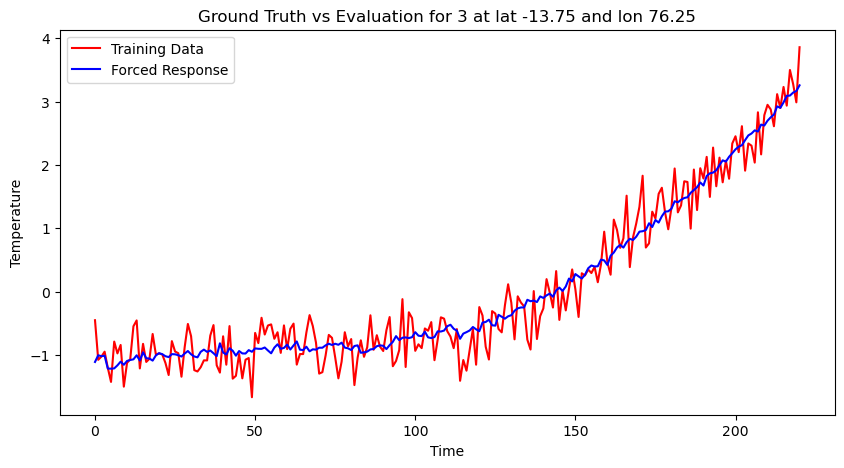

In [12]:
# plot time series in a single grid cell
idx_lat = 30
idx_lon = 30
plt.figure(figsize=(10, 5))
plt.plot(dic_data_yearly['CESM2'][0,:,idx_lat,idx_lon], label='Training Data', color='red')
plt.plot(dic_forced_response_yearly['CESM2'][0,:,idx_lat,idx_lon], label='Forced Response', color='blue')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [13]:
# compute the variance of anomaly per climate model and standardize
means_yearly = {}
vars_yearly = {}
vars = {}
means = {}

# for each model, compute the variance of the anomaly
for dir in DIR_LIST:
    print(f'Computing variance for {dir}')
    # means_yearly[dir] = np.nanmean(dic_data_yearly[dir], axis=0)
    means_yearly[dir] =  np.zeros((dic_data_yearly[dir].shape[1], dic_data_yearly[dir].shape[2], dic_data_yearly[dir].shape[3]), dtype=np.float32)
    vars_yearly[dir] = np.nanvar(dic_data_yearly[dir], axis=0)
    vars[dir] = np.nanvar(dic_data[dir], axis=0)
    means[dir] = np.zeros((dic_data[dir].shape[1], dic_data[dir].shape[2], dic_data[dir].shape[3]), dtype=np.float32)


# normalize the data
# dic_data_tmp = normalize_data(dic_data, means, vars)
# dic_forced_response_tmp = normalize_data(dic_forced_response, means, vars)

# dic_data_yearly_tmp = normalize_data(dic_data_yearly, means_yearly, vars_yearly)
# dic_forced_response_yearly_tmp= normalize_data(dic_forced_response_yearly, means_yearly, vars_yearly)

Computing variance for CESM2
Computing variance for CanESM5
Computing variance for MIROC-ES2L
Computing variance for MIROC6
Computing variance for MPI-ESM1-2-LR


In [14]:
# train the models on yearly data
# compute training set and test set

x_train_yearly, y_train_yearly  = merge_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)
# x_train_yearly_tmp, y_train_yearly_tmp  = merge_training_data(dic_data_yearly_tmp,dic_forced_response_yearly_tmp,dtype=torch.float32)

x_yearly, y_yearly = reshape_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)

# stack all the items in x_yearly and y_yearly
x_yearly_stacked = 0
y_yearly_stacked = 0

for idx,key in enumerate(x_yearly.keys()):

    if idx == 0:
        x_yearly_stacked = x_yearly[key]
        y_yearly_stacked = y_yearly[key]
    else:
        x_yearly_stacked = torch.cat([x_yearly_stacked, x_yearly[key]], dim=0)
        y_yearly_stacked = torch.cat([y_yearly_stacked, y_yearly[key]], dim=0)
print(f'x_yearly_stacked shape: {x_yearly_stacked.shape}')
print(f'y_yearly_stacked shape: {y_yearly_stacked.shape}')

  x_train shape: torch.Size([11050, 10368])
  x_train shape: torch.Size([16575, 10368])
  x_train shape: torch.Size([23205, 10368])
  x_train shape: torch.Size([34255, 10368])
  x_train shape: torch.Size([40885, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([25, 221, 10368])
  y_train shape: torch.Size([25, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])
x_yearly_stacked shape: torch.Size([185, 221, 10368])
y_yearly_stacked shape: torch.Size([185, 221, 10368])


In [15]:
# Use MPS / Cuda or CPU if none of the options are available
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
np.random.seed(42)

Using device: cpu


In [16]:
# Create the DataLoader with x_st
from torch.utils.data import DataLoader, TensorDataset

# Create a TensorDataset
train_dataset = TensorDataset(x_yearly_stacked, y_yearly_stacked)

# Create a DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

from trend_vae import Trend_Vae

# Set VAE parameters
hidden_dim = 128 # Increased for better representation
feat_dim = x_yearly_stacked.shape[2]
latent_dim = 64 # Intermediate layer size
z_dim = 5 # Actual latent space dimension
trend_poly = 2
# seq_len, _ = sample
seq_len = x_yearly_stacked.shape[1]  # Sequence length from the input data
print(f"The sequence length is {seq_len}")
# beta = 0.001      # Weight for KL divergence term -- not used in this version

# Create the model
vae_model = Trend_Vae(
    seq_len=seq_len,
    feat_dim=feat_dim,
    hidden_dim=hidden_dim,
    latent_dim=latent_dim,
    z_dim=z_dim,
    trend_poly=trend_poly,
    use_residual_conn=True,
    device=device,
).to(device)

# Print model summary
print("\nTrend VAE Model Architecture:")
print(vae_model)
print(f"\nTotal parameters: {sum(p.numel() for p in vae_model.parameters() if p.requires_grad):,}")


The sequence length is 221

Trend VAE Model Architecture:
Trend_Vae(
  (encoder): TrendVAEEncoder(
    (encoder): Sequential(
      (0): Conv1d(10368, 128, kernel_size=(3,), stride=(2,), padding=(1,))
      (1): ReLU()
      (2): Conv1d(128, 64, kernel_size=(3,), stride=(2,), padding=(1,))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
    )
    (z_mean): Linear(in_features=3584, out_features=5, bias=True)
    (z_log_var): Linear(in_features=3584, out_features=5, bias=True)
  )
  (decoder): TrendVAEDecoder(
    (level_model): LevelModel(
      (level_dense1): Linear(in_features=5, out_features=10368, bias=True)
      (level_dense2): Linear(in_features=10368, out_features=10368, bias=True)
      (relu): ReLU()
    )
    (trend_layer): TrendLayer(
      (trend_dense1): Linear(in_features=5, out_features=20736, bias=True)
      (trend_dense2): Linear(in_features=20736, out_features=20736, bias=True)
    )
    (residual_conn): ResidualConnection(
      (fc): Linear(in_featur

In [ ]:
from trend_vae import train_vae
# Train the VAE
epochs = 200
losses = []

optimizer = torch.optim.Adam(vae_model.parameters(), lr=3e-4) # Weight decay is not used in this version (was weight_decay=1e-5)

losses = train_vae(vae_model, train_loader, optimizer, epochs=epochs, device=device)


  0%|          | 1/200 [00:06<22:10,  6.69s/it]

Epoch 1, Loss: 127543203.2865


  6%|▌         | 11/200 [01:11<20:10,  6.41s/it]

Epoch 11, Loss: 6511118.7027


 10%|█         | 21/200 [02:15<19:00,  6.37s/it]

Epoch 21, Loss: 2228523.0703
